## Make_circle dataset

In [2]:
import torch

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f'Using device ={device}')

Using device =cpu


Shape of X and y = (1000, 2), (1000,)


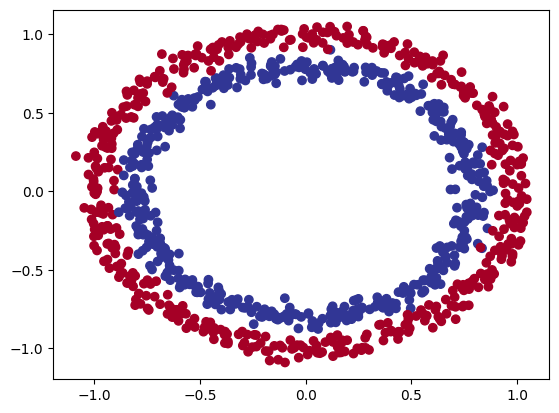

In [4]:
# make_circle dataset
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

X, y = make_circles(n_samples=1000, noise=0.04, random_state=42)

print(f"Shape of X and y = {X.shape}, {y.shape}")
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);

In [5]:
# Train-test Split
from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Define the model class
from torch import nn
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
        
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [7]:
# Instantiate the model and inspect parameters
model = CircleModel()
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.2920,  0.2499],
                      [ 0.4439,  0.3684],
                      [ 0.5509, -0.0863],
                      [-0.2422, -0.6978],
                      [-0.6189,  0.1021],
                      [-0.0181,  0.3568],
                      [ 0.5673,  0.3696],
                      [-0.0221, -0.0863],
                      [-0.2165, -0.2946],
                      [-0.3756, -0.1419]])),
             ('layer_1.bias',
              tensor([-0.3956,  0.1627,  0.5395,  0.2235, -0.6837,  0.6427, -0.5798,  0.2664,
                      -0.1371,  0.3775])),
             ('layer_2.weight',
              tensor([[-2.8644e-01, -5.5576e-02,  7.0796e-02, -1.0358e-01,  6.6147e-02,
                       -2.6740e-01, -2.5006e-02, -2.2726e-01,  1.9606e-01,  1.3983e-01],
                      [ 1.7398e-01,  2.6145e-01,  8.5896e-02,  2.4212e-01,  6.7388e-02,
                        1.8291e-01, -8.8992e-02, -1.6647e-01,  3.0729e-01,  5.850

In [8]:
# Define loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.05)

In [9]:
# define an accuracy function
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_true))*100
    return acc

In [10]:
# Training Loop
epochs = 2500
train_loss_list = []
test_loss_list = []
torch.manual_seed(42)
# Cast the model and data to the device
model.to(device)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### TRAINING
    model.train()

    # Forward Pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Compute Loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # Optimizer Zero Grad
    optimizer.zero_grad()

    # Backpropagate
    loss.backward()

    # Step the optimizer
    optimizer.step()

    ### TESTING
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)
    train_loss_list.append(loss.item())
    test_loss_list.append(test_loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1}|Loss {loss:.5f}|Acc {acc:.2f}|Test Loss {test_loss:.5f}|Test Acc {test_acc:.2f}')

Epoch 100|Loss 0.69027|Acc 50.62|Test Loss 0.69225|Test Acc 50.00
Epoch 200|Loss 0.68940|Acc 58.50|Test Loss 0.69185|Test Acc 51.50
Epoch 300|Loss 0.68850|Acc 61.50|Test Loss 0.69154|Test Acc 52.50
Epoch 400|Loss 0.68732|Acc 62.75|Test Loss 0.69105|Test Acc 54.50
Epoch 500|Loss 0.68578|Acc 62.62|Test Loss 0.69025|Test Acc 57.00
Epoch 600|Loss 0.68412|Acc 63.62|Test Loss 0.68937|Test Acc 57.50
Epoch 700|Loss 0.68216|Acc 63.38|Test Loss 0.68821|Test Acc 57.50
Epoch 800|Loss 0.67979|Acc 63.50|Test Loss 0.68673|Test Acc 57.00
Epoch 900|Loss 0.67690|Acc 63.62|Test Loss 0.68476|Test Acc 56.50
Epoch 1000|Loss 0.67334|Acc 63.25|Test Loss 0.68216|Test Acc 55.50
Epoch 1100|Loss 0.66881|Acc 62.12|Test Loss 0.67859|Test Acc 55.00
Epoch 1200|Loss 0.66308|Acc 62.38|Test Loss 0.67400|Test Acc 55.50
Epoch 1300|Loss 0.65585|Acc 62.25|Test Loss 0.66800|Test Acc 55.50
Epoch 1400|Loss 0.64637|Acc 63.75|Test Loss 0.65940|Test Acc 57.50
Epoch 1500|Loss 0.63327|Acc 64.88|Test Loss 0.64717|Test Acc 61.50
Epoc

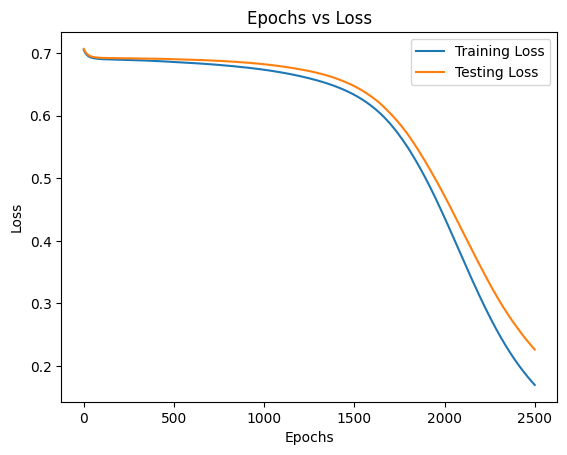

In [11]:
# Plot loss curve
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Epochs vs Loss");

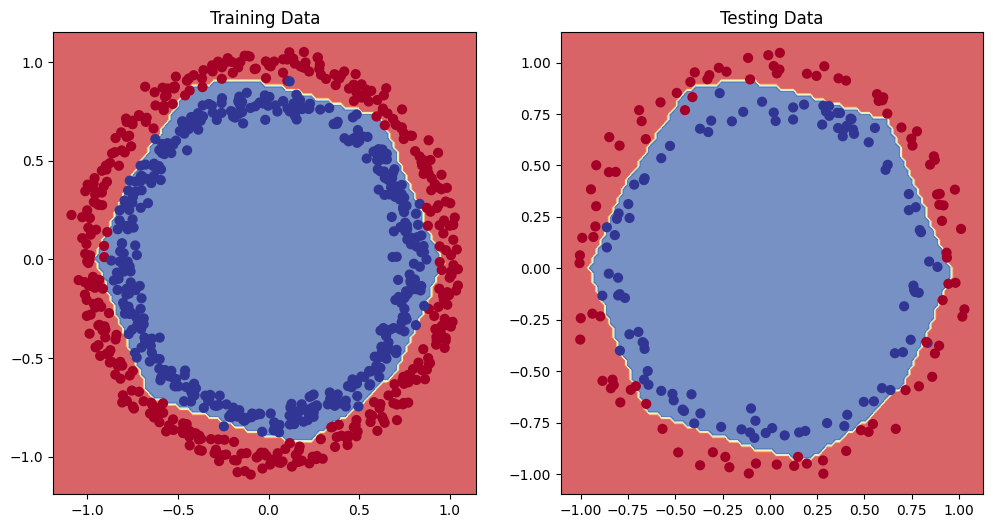

In [12]:
# Visualize the decision boundry
from helper_functions import plot_decision_boundary

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training Data")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Testing Data")
plot_decision_boundary(model, X_test, y_test)